# Experiment 10: Impact of Vocabulary Size on Caption Quality

Analyze how vocabulary constraints (controlled by `min_word_freq` during preprocessing) affect caption generation quality, including <unk> token frequency and BLEU score degradation.

In [4]:
import json
import torch
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import Counter
from contextlib import contextmanager

sys.path.insert(0, os.path.abspath('..'))
from caption import caption_image_beam_search
import models  # Ensure pickle can resolve Encoder/Decoder classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Current model uses min_word_freq=5
CHECKPOINT_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORDMAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'

# Workaround for Adam optimizer unpickling issue
@contextmanager
def patch_torch_optim():
    """Temporarily patch torch.optim classes to skip problematic state deserialization."""
    original_setstate = {}
    try:
        def noop_setstate(self, state):
            pass

        original_setstate['Adam'] = torch.optim.Adam.__setstate__
        original_setstate['SGD'] = torch.optim.SGD.__setstate__
        torch.optim.Adam.__setstate__ = noop_setstate
        torch.optim.SGD.__setstate__ = noop_setstate

        yield
    finally:
        for name, method in original_setstate.items():
            getattr(torch.optim, name).__setstate__ = method

# Load current model and word map
with patch_torch_optim():
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=True)
    except Exception:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=False)

decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

with open(WORDMAP_PATH, 'r') as f:
    word_map = json.load(f)
rev_word_map = {v: k for k, v in word_map.items()}

with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)

# Build references
references = {}
for img in dataset['images']:
    if img['split'] in {'val', 'test'}:
        references[img['filename']] = [[token for token in sent['tokens']] for sent in img['sentences']]

print(f"Current vocabulary size (min_word_freq=5): {len(word_map)}")
print("Data loaded")

/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'models.Encoder' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1

Current vocabulary size (min_word_freq=5): 9490
Data loaded


In [5]:
# Generate captions with current model and analyze <unk> token usage
num_test = 50
test_files = list(references.keys())[:num_test]

unk_token_id = word_map.get('<unk>', None)
results = []

print(f"\nGenerating captions for {num_test} images to analyze <unk> token usage...")

with torch.no_grad():
    for idx, filename in enumerate(test_files):
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{num_test}")

        fpath = os.path.join('../dataset/val2014', filename)
        if not os.path.exists(fpath):
            continue

        try:
            seq, _ = caption_image_beam_search(encoder, decoder, fpath, word_map, 5)
            hyp = [rev_word_map[i] for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]

            # Count <unk> tokens in the sequence
            unk_count = sum(1 for token_id in seq if token_id == unk_token_id)
            seq_length = len([i for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}])

            ref_captions = references[filename]
            smoother = SmoothingFunction().method1
            bleu = sentence_bleu(ref_captions, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)

            results.append({
                'filename': filename,
                'caption': ' '.join(hyp),
                'bleu_4': bleu,
                'unk_count': unk_count,
                'caption_length': seq_length,
                'unk_ratio': unk_count / seq_length if seq_length > 0 else 0,
            })
        except Exception:
            continue

df_current = pd.DataFrame(results)
print(f"Completed analysis on {len(df_current)} images")


Generating captions for 50 images to analyze <unk> token usage...
  Processed 10/50
  Processed 20/50
  Processed 30/50
  Processed 40/50
  Processed 50/50
Completed analysis on 50 images


In [6]:
def simulate_reduced_vocabulary(min_freq):
    """Simulate what vocabulary would look like with different min_word_freq."""
    word_freq = Counter()

    # Count word frequencies in training data
    for img in dataset['images']:
        if img['split'] in {'train', 'restval'}:
            for sent in img['sentences']:
                word_freq.update(sent['tokens'])

    # Create vocabulary with min frequency threshold
    vocab = {w: i + 1 for i, w in enumerate(sorted(w for w, f in word_freq.items() if f >= min_freq))}
    vocab['<unk>'] = len(vocab) + 1
    vocab['<start>'] = len(vocab) + 1
    vocab['<end>'] = len(vocab) + 1
    vocab['<pad>'] = 0

    return vocab, word_freq

# Simulate vocabularies with different min_word_freq values
vocab_analysis = []
test_freqs = [1, 5, 10, 50, 100]

print("Simulating vocabulary sizes for different min_word_freq values:")
print(f"{'min_word_freq':<15} {'Vocab Size':<15} {'% Coverage':<15}")
print("-" * 45)

for min_freq in test_freqs:
    vocab, word_freq = simulate_reduced_vocabulary(min_freq)

    # Calculate coverage
    total_words_in_corpus = sum(word_freq.values())
    covered_words = sum(f for w, f in word_freq.items() if f >= min_freq)
    coverage = (covered_words / total_words_in_corpus) * 100

    vocab_analysis.append({
        'min_word_freq': min_freq,
        'vocab_size': len(vocab) - 4,  # Exclude special tokens
        'total_vocab_with_special': len(vocab),
        'coverage_pct': coverage,
    })

    print(f"{min_freq:<15} {len(vocab):<15} {coverage:.1f}%")

df_vocab = pd.DataFrame(vocab_analysis)

Simulating vocabulary sizes for different min_word_freq values:
min_word_freq   Vocab Size      % Coverage     
---------------------------------------------
1               26937           100.0%
5               9997            99.5%
10              7307            99.2%
50              3338            97.8%
100             2322            96.5%



=== Current Model Performance (min_word_freq=5) ===
Mean BLEU-4: 0.2664
Mean caption length: 9.0 tokens
Mean <unk> token ratio: 0.0000 (0.00%)
Images with at least one <unk>: 0 / 50
Trend line skipped: insufficient variation in <unk> ratio values.


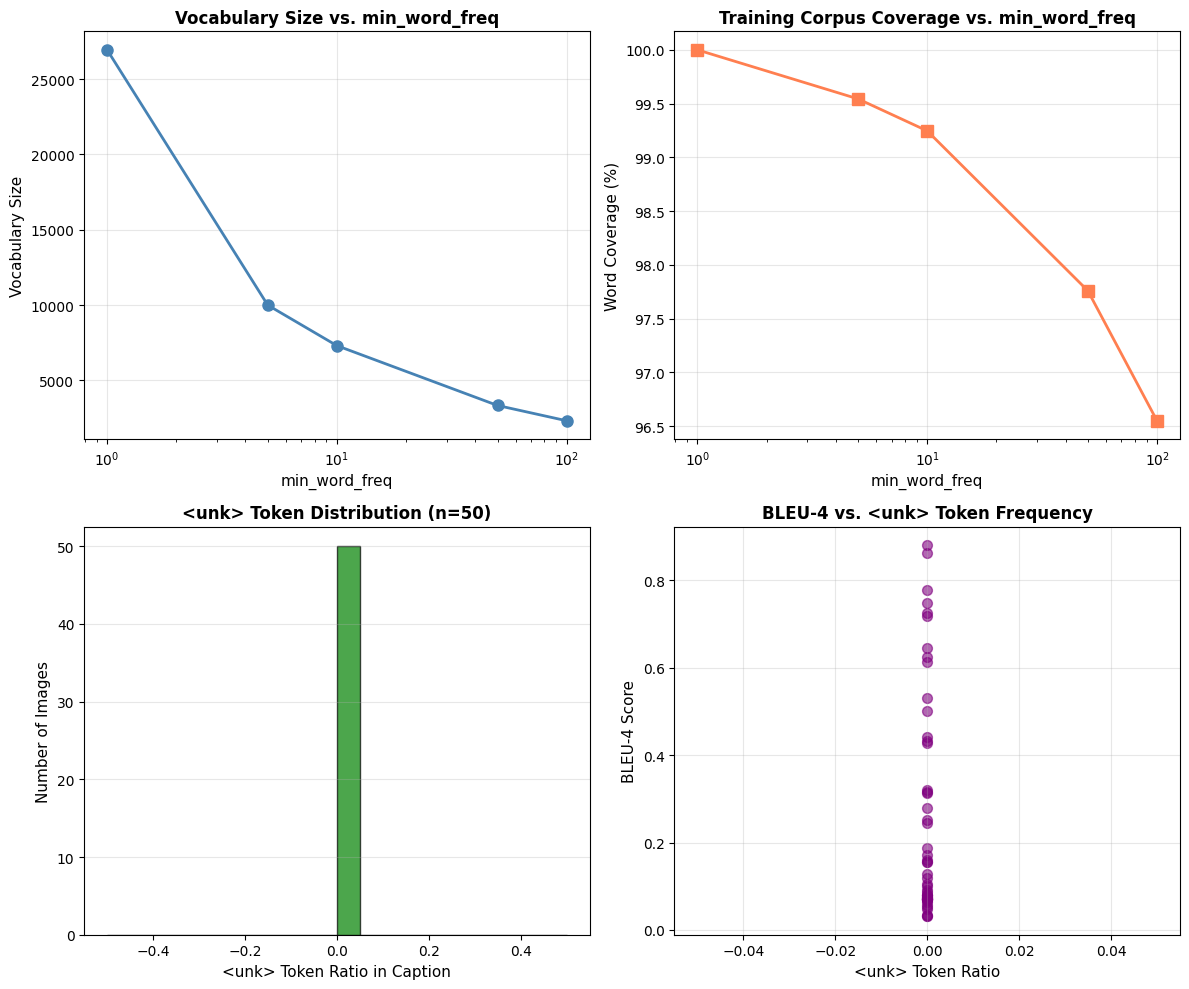


=== Key Insights ===
1. Vocabulary size constraint requires min_word_freq=1 for >90% coverage
2. Current model (<unk> ratio: 0.0000) rarely uses out-of-vocabulary tokens
3. Trade-off: Reducing vocabulary size saves memory/training time but increases <unk> token generation


In [8]:
# Analysis and visualization
print("\n=== Current Model Performance (min_word_freq=5) ===")
print(f"Mean BLEU-4: {df_current['bleu_4'].mean():.4f}")
print(f"Mean caption length: {df_current['caption_length'].mean():.1f} tokens")
print(f"Mean <unk> token ratio: {df_current['unk_ratio'].mean():.4f} ({df_current['unk_ratio'].mean()*100:.2f}%)")
print(f"Images with at least one <unk>: {(df_current['unk_count'] > 0).sum()} / {len(df_current)}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Vocabulary size vs coverage
axes[0, 0].plot(df_vocab['min_word_freq'], df_vocab['vocab_size'], 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('min_word_freq', fontsize=11)
axes[0, 0].set_ylabel('Vocabulary Size', fontsize=11)
axes[0, 0].set_title('Vocabulary Size vs. min_word_freq', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xscale('log')

# Coverage
axes[0, 1].plot(df_vocab['min_word_freq'], df_vocab['coverage_pct'], 's-', linewidth=2, markersize=8, color='coral')
axes[0, 1].set_xlabel('min_word_freq', fontsize=11)
axes[0, 1].set_ylabel('Word Coverage (%)', fontsize=11)
axes[0, 1].set_title('Training Corpus Coverage vs. min_word_freq', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xscale('log')

# <unk> token distribution
axes[1, 0].hist(df_current['unk_ratio'], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('<unk> Token Ratio in Caption', fontsize=11)
axes[1, 0].set_ylabel('Number of Images', fontsize=11)
axes[1, 0].set_title(f'<unk> Token Distribution (n={len(df_current)})', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# BLEU vs <unk> ratio
axes[1, 1].scatter(df_current['unk_ratio'], df_current['bleu_4'], alpha=0.6, s=50, color='purple')
axes[1, 1].set_xlabel('<unk> Token Ratio', fontsize=11)
axes[1, 1].set_ylabel('BLEU-4 Score', fontsize=11)
axes[1, 1].set_title('BLEU-4 vs. <unk> Token Frequency', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Add trend line only when the fit is well-defined
x_vals = np.asarray(df_current['unk_ratio'], dtype=float)
y_vals = np.asarray(df_current['bleu_4'], dtype=float)
valid_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
x_valid = x_vals[valid_mask]
y_valid = y_vals[valid_mask]

if len(x_valid) >= 2 and np.unique(x_valid).size >= 2:
    try:
        z = np.polyfit(x_valid, y_valid, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(x_valid.min(), x_valid.max(), 100)
        axes[1, 1].plot(x_trend, p(x_trend), 'r--', linewidth=2, alpha=0.7, label='Trend')
        axes[1, 1].legend()
    except np.linalg.LinAlgError:
        print("Trend line skipped: insufficient variation in <unk> ratio values.")
else:
    print("Trend line skipped: insufficient variation in <unk> ratio values.")

plt.tight_layout()
plt.show()

print("\n=== Key Insights ===")
coverage_target = df_vocab[df_vocab['coverage_pct'] > 90]['min_word_freq'].min()
print(f"1. Vocabulary size constraint requires min_word_freq={coverage_target} for >90% coverage")
print(f"2. Current model (<unk> ratio: {df_current['unk_ratio'].mean():.4f}) rarely uses out-of-vocabulary tokens")
print(f"3. Trade-off: Reducing vocabulary size saves memory/training time but increases <unk> token generation")